In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from few.waveform import GenerateEMRIWaveform, FastSchwarzschildEccentricFlux, FastKerrEccentricEquatorialFlux


import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [2]:
import stableemrifisher
stableemrifisher.__file__
from tqdm import tqdm
from stableemrifisher.fisher.fisher import StableEMRIFisher


startup


# Set Up

In [3]:
# GPU configuration
use_gpu = True
dt = 10     # Time step
T = 0.25   # Total time

# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
        "err": 1e-15  # Error tolerance 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": "cuda12x" # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs = {
    "force_backend": "cuda12x",  # Force GPU
    "pad_output": True
}

waveform_class = FastKerrEccentricEquatorialFlux
waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                             amplitude_kwargs=amplitude_kwargs,
                             Ylm_kwargs=Ylm_kwargs,
                             sum_kwargs=sum_kwargs,
                             use_gpu=use_gpu)

 
#waveform generator setup
waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(frame='detector')

waveform_gen = GenerateEMRIWaveform(
    waveform_class, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs,
    use_gpu=use_gpu
)

In [4]:
gwf = GWfuncs.GravWaveAnalysis(T, dt)

In [5]:
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                      stats_for_nerds = True, use_gpu = use_gpu,
                      deriv_type='stable')


In [6]:
# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 7.5
e0 = 0.4 
xI0 = 1.0
dist = 2 # Gpc
# Polar and azimuthal angles .. detector frame
# S = Solar system barycenter
# K = spin angular momentum of the MBH
qS = 0.5 
phiS = 1 
qK = 1 #fixed
phiK = phiS + np.pi/3
# Phases
Phi_phi0 = 0.4
Phi_theta0 = 0.0 # equatorial
Phi_r0 = 0.5


In [7]:
waveform = waveform_gen(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,  T=T, dt=dt)

In [8]:
hf = gwf.freq_wave(waveform)
np.sqrt(gwf.inner(hf,hf))

array(26.8598654)

# Computing Fisher 

T:  0.25 dt:  10
Body is not plunging, Fisher should be stable.


wave ndim: 2
Computing SNR for parameters: (1000000.0, 30.0, 0.7, 7.5, 0.4, 1.0, 2, 0.5, 1, 1, 2.0471975511965974, 0.4, 0.0, 0.5)
Waveform Generated. SNR: 683.2920515495285
calculating stable deltas...
Gamma_ii for m1: 7840.861114416181
Gamma_ii for m1: 7840.8611142641175
Gamma_ii for m1: 7840.861114289249
Gamma_ii for m1: 7840.86111494955
Gamma_ii for m1: 7840.8611160745395
Gamma_ii for m1: 7840.86108089527
Gamma_ii for m1: 7840.860764827611
Gamma_ii for m1: 7840.862116124403
[1.9393772436676817e-11, 3.205152754662409e-12, 8.421285994729807e-11, 1.43477795392902e-10, 4.48665895920647e-09, 4.0310326667779745e-08, 1.7234033345327384e-07]
1


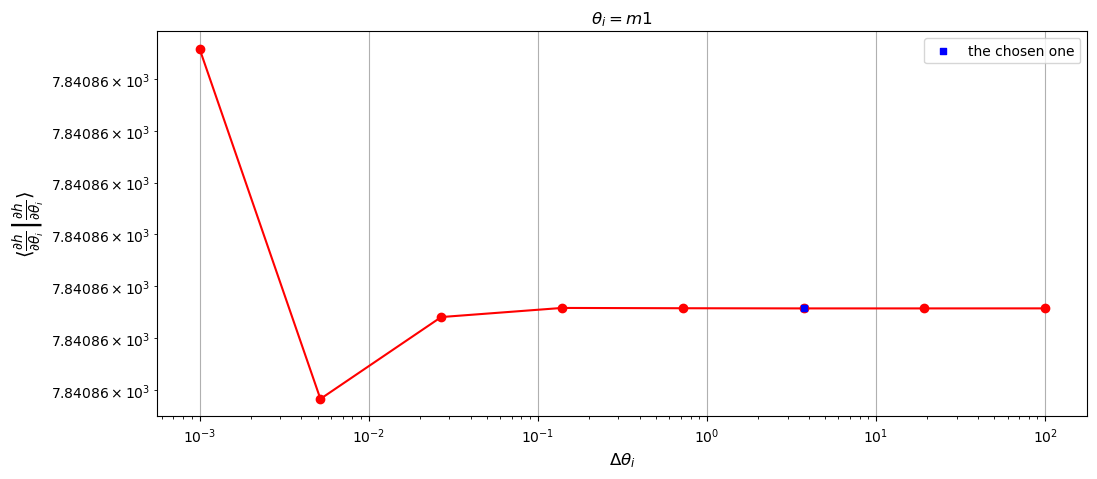

Gamma_ii for m2: 285723364340.18164
Gamma_ii for m2: 285723364338.9282
Gamma_ii for m2: 285723364271.36755
Gamma_ii for m2: 285723363591.2391
Gamma_ii for m2: 285723365728.29504
Gamma_ii for m2: 285723357428.27734
Gamma_ii for m2: 285723260634.94794
Gamma_ii for m2: 285723191410.3177
[4.386823498491295e-12, 2.364548279683083e-10, 2.3803740459142507e-09, 7.479458194785817e-09, 2.904913961148169e-08, 3.387660115303161e-07, 2.4227865406141366e-07]
0


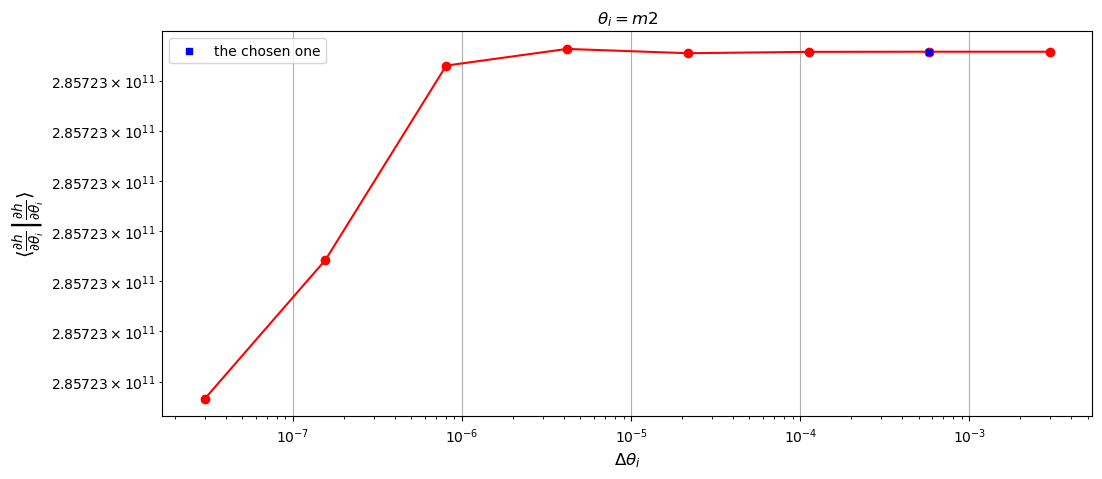

Gamma_ii for a: 597858489564753.9
Gamma_ii for a: 597858629568036.4
Gamma_ii for a: 597858286414045.8
Gamma_ii for a: 597857602995726.6
Gamma_ii for a: 597831599176024.4
Gamma_ii for a: 597885025744113.0
Gamma_ii for a: 599136339881896.0
Gamma_ii for a: 601576925834944.2
[2.3417456163701257e-07, 5.739721242022717e-07, 1.1431121987920674e-06, 4.349689735050871e-05, 8.935926773233969e-05, 0.0020885298628850715, 0.0040569806590585195]
0


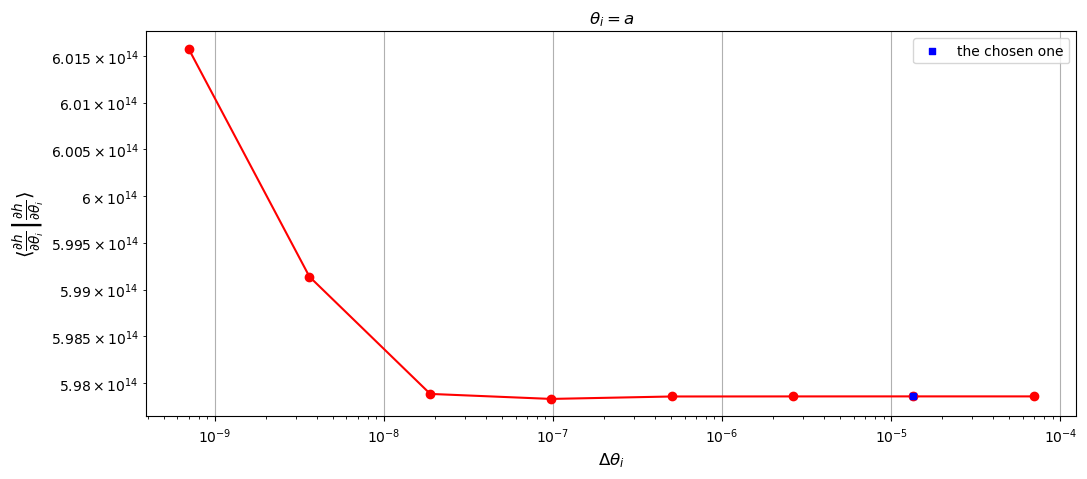

Gamma_ii for p0: 422709917973544.9
Gamma_ii for p0: 422709915271782.44
Gamma_ii for p0: 422709928860782.4
Gamma_ii for p0: 422710106271822.44
Gamma_ii for p0: 422709968672415.75
Gamma_ii for p0: 422712680967470.56
Gamma_ii for p0: 422704138303049.0
Gamma_ii for p0: 422589614333581.2
[6.391528421477634e-09, 3.214734031472319e-08, 4.1969907373924097e-07, 3.2551729763944683e-07, 6.416403332412026e-06, 2.0209559470737932e-05, 0.00027100516809532916]
0


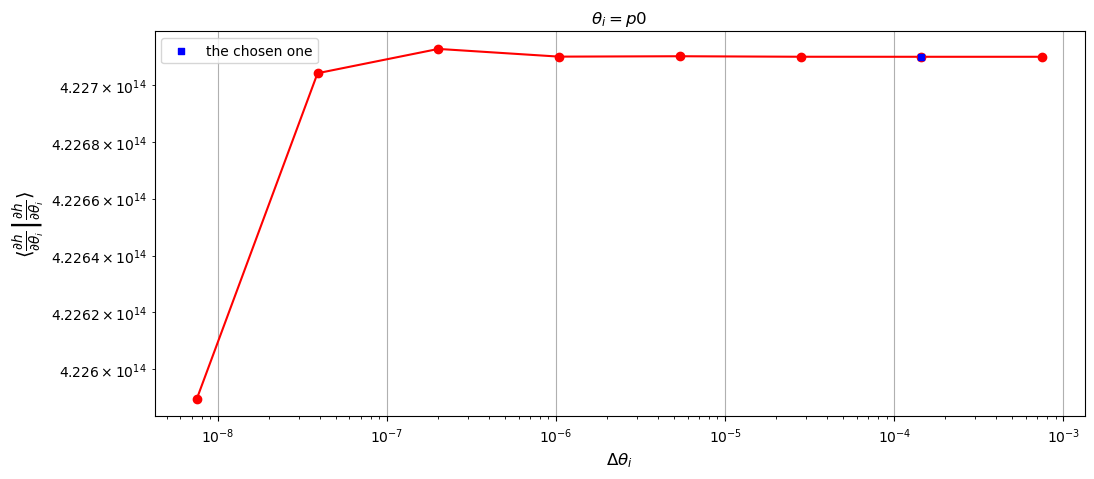

Gamma_ii for e0: 2382642106935519.0
Gamma_ii for e0: 2382642196608284.0
Gamma_ii for e0: 2382642277631550.0
Gamma_ii for e0: 2382643099015182.5
Gamma_ii for e0: 2382607029634310.0
Gamma_ii for e0: 2382804639714449.0
Gamma_ii for e0: 2380442897132164.0
Gamma_ii for e0: 2382972659410771.0
[3.763585028740367e-08, 3.400563599523662e-08, 3.447363278367215e-07, 1.5138619345900293e-05, 8.293171703857402e-05, 0.0009921441867520985, 0.001061599371951051]
1


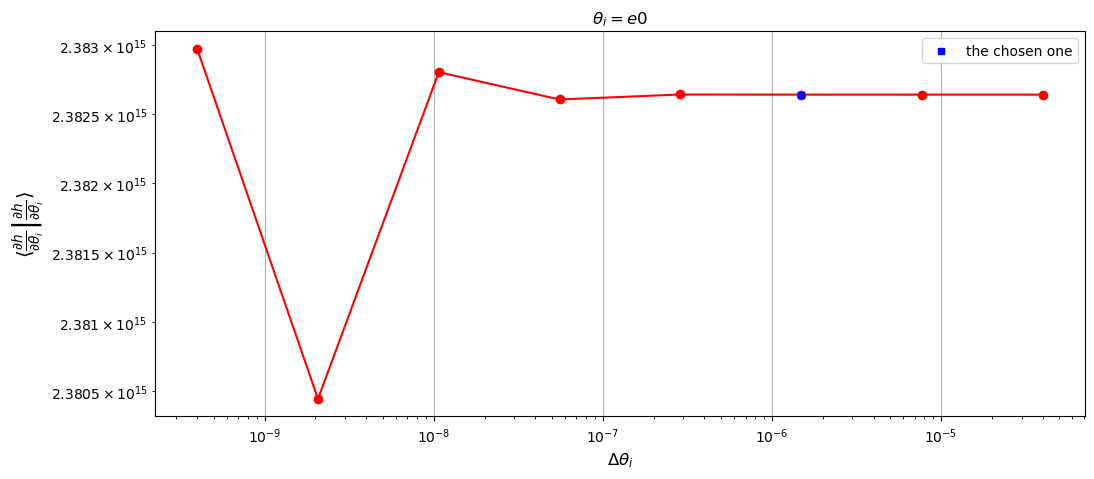

Gamma_ii for qS: 1549023.96912753
Gamma_ii for qS: 1549024.027954124
Gamma_ii for qS: 1549024.028036006
Gamma_ii for qS: 1549024.0280361106
Gamma_ii for qS: 1549024.0280360647
Gamma_ii for qS: 1549024.028036071
Gamma_ii for qS: 1549024.0280401392
Gamma_ii for qS: 1549024.0280554448
[3.797655352880218e-08, 5.286045413682455e-11, 6.748827462226456e-14, 2.961066837547107e-14, 4.0583149550137855e-15, 2.626331007732209e-12, 9.880794451644613e-12]
4


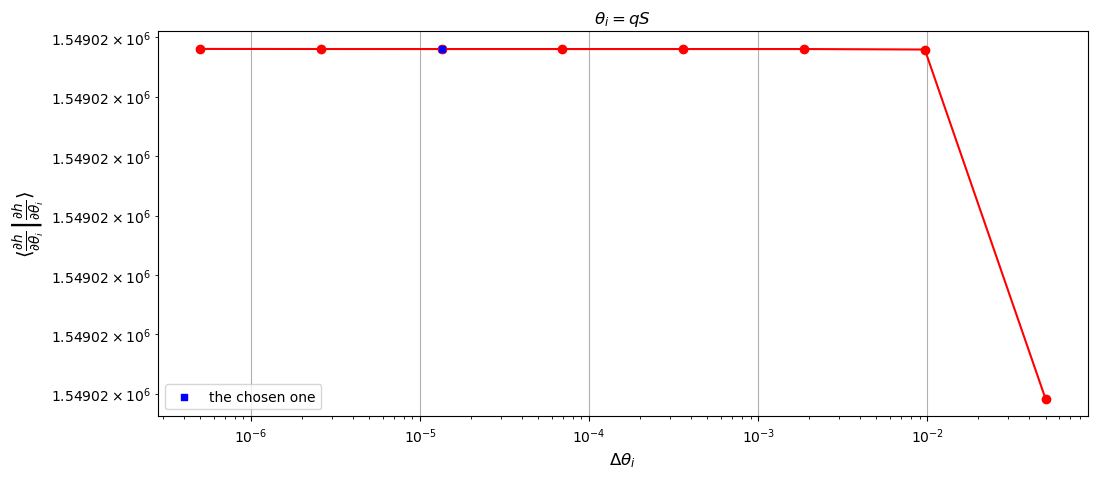

Gamma_ii for phiS: 1751151.922752818
Gamma_ii for phiS: 1751156.4615839773
Gamma_ii for phiS: 1751156.467922713
Gamma_ii for phiS: 1751156.4679315456
Gamma_ii for phiS: 1751156.4679323137
Gamma_ii for phiS: 1751156.4679327554
Gamma_ii for phiS: 1751156.4679471536
Gamma_ii for phiS: 1751156.467989035
[2.5919049832555317e-06, 3.619742548898723e-09, 5.043902963215093e-12, 4.3862916163114965e-13, 2.5222173980420763e-13, 8.222136209469666e-12, 2.3916391319337354e-11]
4


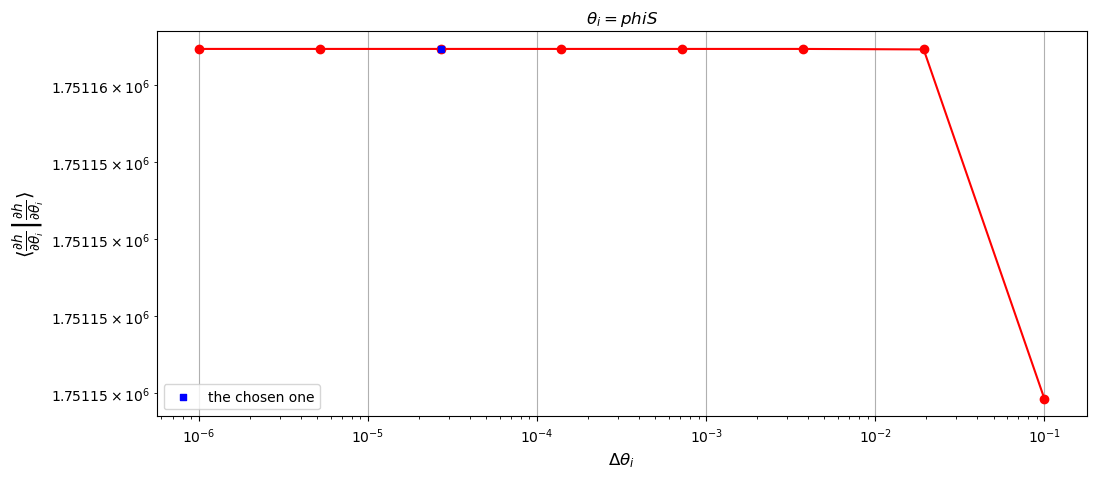

stable deltas: {'m1': 3.72759372031494, 'm2': 0.0005792093186649751, 'a': 1.351488410218275e-05, 'p0': 0.0001448023296662437, 'e0': 1.4910374881259754e-06, 'dist': 0.0, 'qS': 1.3413478976398634e-05, 'phiS': 2.6826957952797274e-05, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 444.6092884540558 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 64.2403678894043 seconds


In [9]:
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
# NOTE: leaving off xI0 and Phi_theta0 for now as fixed
param_names = ['m1','m2','a','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0']
der_order = 4
Ndelta = 8
stability_plot = True
# using default delta range first by SEF
Fisher = sef(*pars_list, param_names = param_names, 
             T = T, dt = dt, 
             der_order = der_order, 
             Ndelta = Ndelta, 
             stability_plot = stability_plot,
            #  delta_range = delta_range,
            live_dangerously = False)

In [10]:
np.linalg.eigvals(Fisher)

array([3.22059144e+15, 1.79443571e+14, 3.46126020e+12, 2.81223141e+08,
       7.71516896e+05, 2.02006863e+05, 1.27234589e+05, 8.88657341e-04,
       1.99794652e+04, 5.15252455e+03])

In [11]:
# CHAIN RULE FOR FISHER
J_mx = np.eye(10)
J_mx[0, 0] = m1 * np.log(10) 
J_mx[1, 1] = m2 * np.log(10) 
J_mx[6, 6] = -1/np.sin(qS)

Fisher_scaled = J_mx.T @ Fisher @ J_mx

(<Figure size 2000x2000 with 55 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [

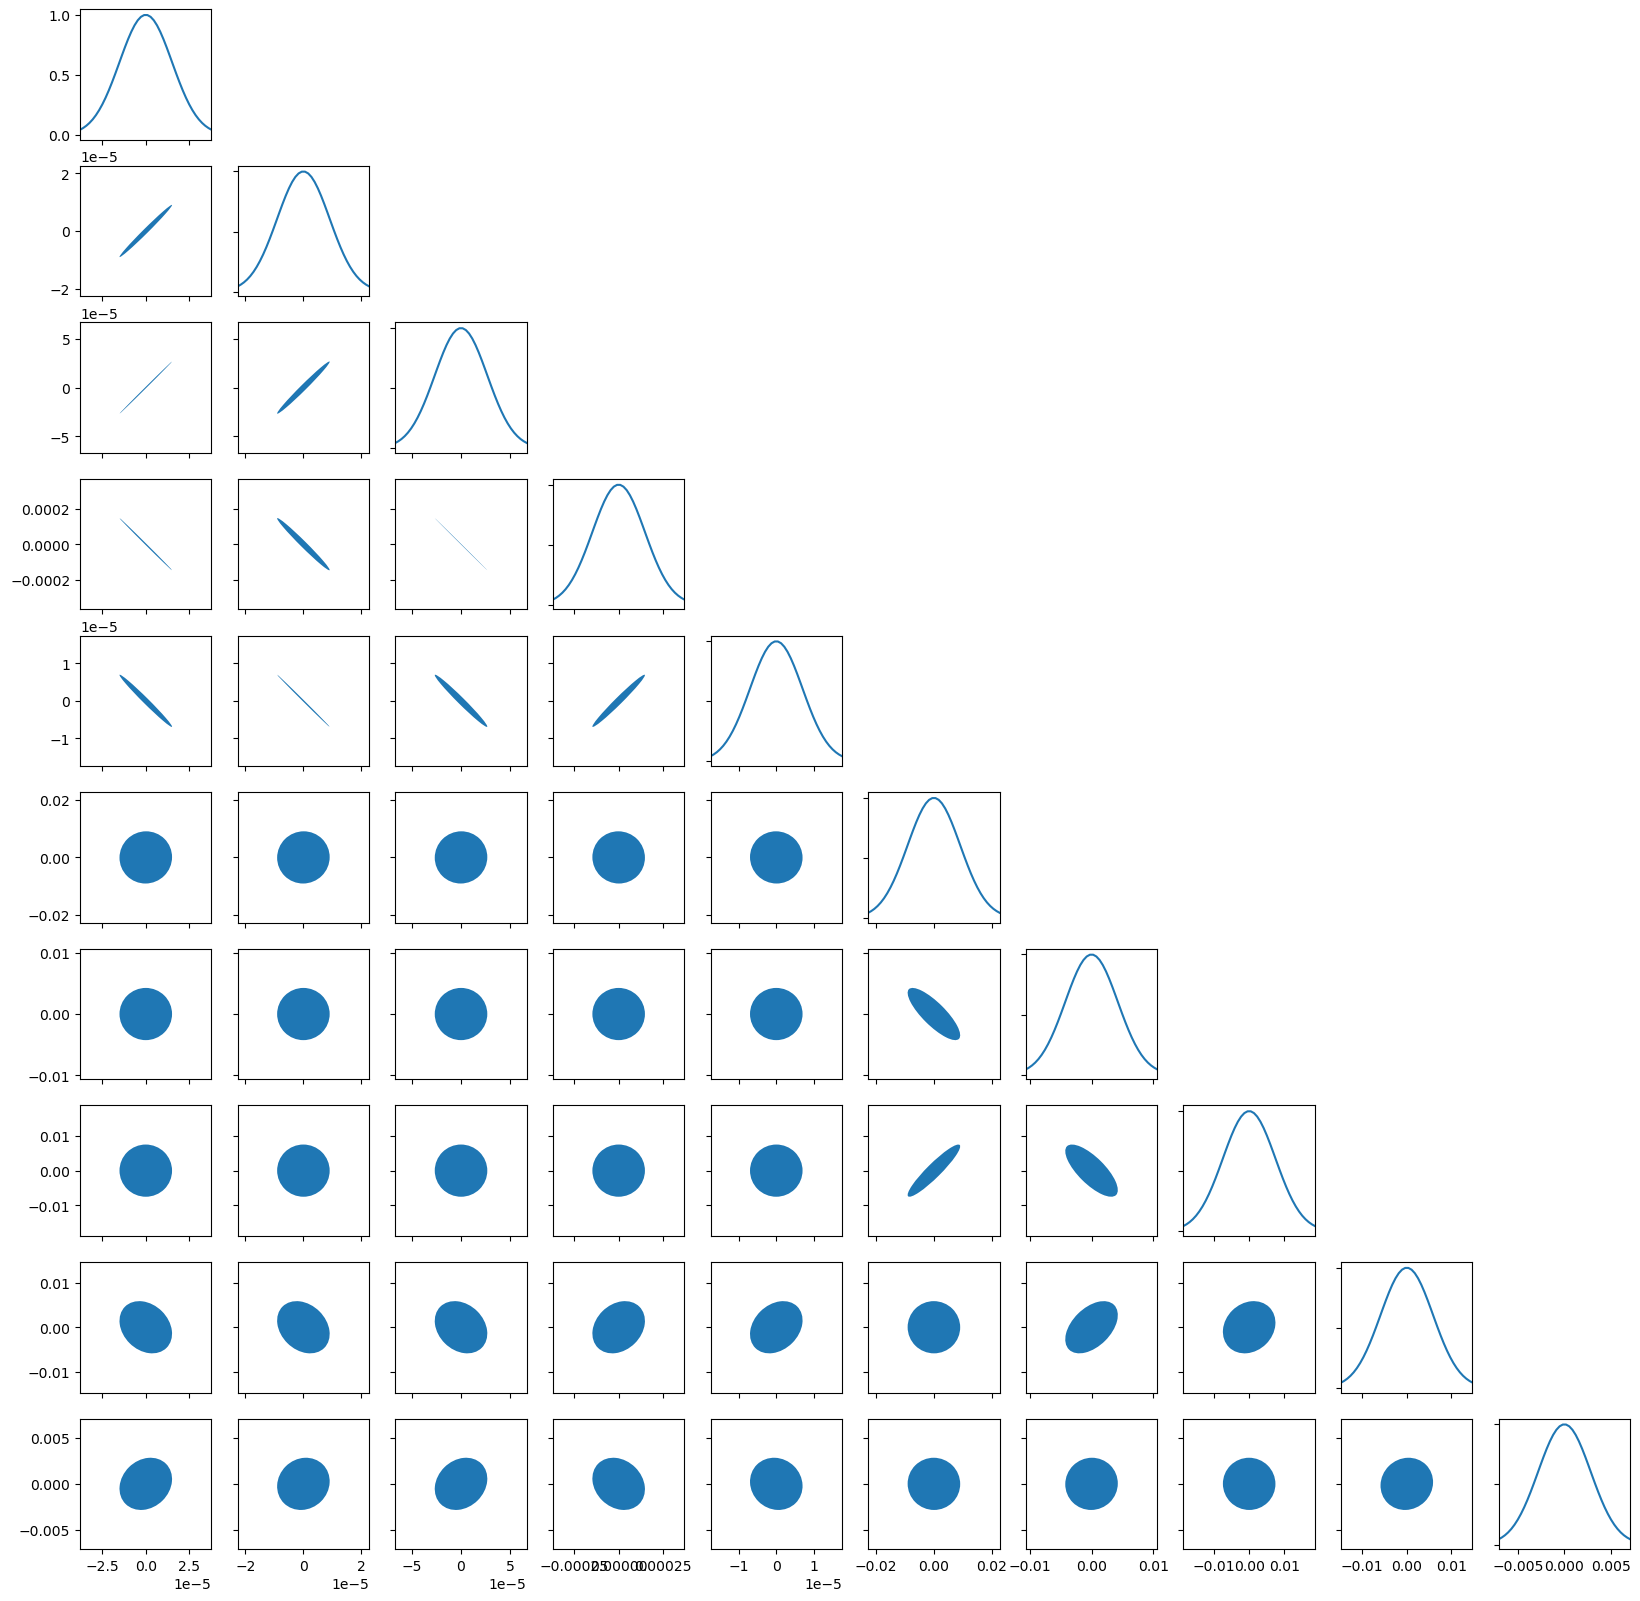

In [12]:
from stableemrifisher.plot import CovEllipsePlot

CovEllipsePlot(np.linalg.inv(Fisher_scaled))

In [13]:
cov = np.linalg.inv(Fisher_scaled)
cov

array([[ 2.28464724e-10,  1.35959601e-10,  4.05739062e-10,
        -2.23158181e-09, -1.04529443e-10,  1.71902420e-09,
         5.47861418e-11, -2.23931130e-10, -2.20206271e-08,
         7.83535014e-09],
       [ 1.35959601e-10,  8.22678406e-11,  2.40628463e-10,
        -1.32199785e-09, -6.34146025e-11,  1.03484451e-09,
         3.24603111e-11, -1.35795104e-10, -1.37961266e-08,
         2.50787985e-09],
       [ 4.05739062e-10,  2.40628463e-10,  7.21171665e-10,
        -3.96703712e-09, -1.84845896e-10,  3.03897299e-09,
         9.68822563e-11, -4.03964202e-10, -3.83609490e-08,
         1.49119596e-08],
       [-2.23158181e-09, -1.32199785e-09, -3.96703712e-09,
         2.18247017e-08,  1.01550930e-09, -1.67177588e-08,
        -5.41733919e-10,  2.19536501e-09,  2.11119506e-07,
        -8.56506349e-08],
       [-1.04529443e-10, -6.34146025e-11, -1.84845896e-10,
         1.01550930e-09,  4.89469419e-11, -7.99384604e-10,
        -2.55698770e-11,  1.01728152e-10,  1.10103419e-08,
        -1.

In [14]:
np.diag(cov)

array([2.28464724e-10, 8.22678406e-11, 7.21171665e-10, 2.18247017e-08,
       4.89469419e-11, 8.26141120e-05, 1.81774958e-05, 5.62270913e-05,
       3.47079577e-05, 8.00469583e-06])

In [15]:
sigmas = np.sqrt(np.diag(cov))
sigmas

array([1.51150496e-05, 9.07016210e-06, 2.68546395e-05, 1.47731858e-04,
       6.99620911e-06, 9.08923055e-03, 4.26350746e-03, 7.49847260e-03,
       5.89134600e-03, 2.82925712e-03])

In [16]:
log_m1 = np.log10(m1)
log_m2 = np.log10(m2)  
cos_qS = np.cos(qS)

transformed_params = [log_m1, log_m2, a, p0, e0, dist, cos_qS, phiS, Phi_phi0, Phi_r0]
transformed_names = ['log_m1', 'log_m2', 'a', 'p0', 'e0', 'dist', 'cos_qS', 'phiS', 'Phi_phi0', 'Phi_r0']


In [17]:
for i, name in enumerate(transformed_names):
    param_value = transformed_params[i]
    result_low = param_value - sigmas[i]
    result_high = param_value + sigmas[i] 
    prior_low = param_value - 3*sigmas[i]
    prior_high = param_value + 3*sigmas[i]
    
    print(f"=== {name}: {param_value} +/- {sigmas[i]}")
    print(f"3-sigma prior range: [{prior_low:.10e}, {prior_high:.10e}]")

=== log_m1: 6.0 +/- 1.5115049585719474e-05
3-sigma prior range: [5.9999546549e+00, 6.0000453451e+00]
=== log_m2: 1.4771212547196624 +/- 9.070162101815586e-06
3-sigma prior range: [1.4770940442e+00, 1.4771484652e+00]
=== a: 0.7 +/- 2.6854639538955262e-05
3-sigma prior range: [6.9991943608e-01, 7.0008056392e-01]
=== p0: 7.5 +/- 0.00014773185757078157
3-sigma prior range: [7.4995568044e+00, 7.5004431956e+00]
=== e0: 0.4 +/- 6.9962091120260675e-06
3-sigma prior range: [3.9997901137e-01, 4.0002098863e-01]
=== dist: 2 +/- 0.009089230553048482
3-sigma prior range: [1.9727323083e+00, 2.0272676917e+00]
=== cos_qS: 0.8775825618903728 +/- 0.004263507458024403
3-sigma prior range: [8.6479203952e-01, 8.9037308426e-01]
=== phiS: 1 +/- 0.00749847260096001
3-sigma prior range: [9.7750458220e-01, 1.0224954178e+00]
=== Phi_phi0: 0.4 +/- 0.005891345999342974
3-sigma prior range: [3.8232596200e-01, 4.1767403800e-01]
=== Phi_r0: 0.5 +/- 0.002829257116651039
3-sigma prior range: [4.9151222865e-01, 5.0848777

In [18]:
for i, name in enumerate(transformed_names):
    param_value = transformed_params[i]
    result_low = param_value - sigmas[i]
    result_high = param_value + sigmas[i] 
    prior_low = param_value - 1*sigmas[i]
    prior_high = param_value + 1*sigmas[i]
    
    print(f"=== {name}: {param_value} +/- {sigmas[i]}")
    print(f"1-sigma prior range: [{prior_low:.10e}, {prior_high:.10e}]")

: 

In [21]:
# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/sampling_test')

In [22]:
import pickle
with open('cov_matrix_new.pkl', 'wb') as f:
    pickle.dump(cov, f)